In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadr import read_r
import numpy as np

ling_data = pd.read_csv('../data/lingData.txt', sep='\\s+')
ling_location = pd.read_csv('../data/lingLocation.txt', sep='\\s+')


question_data = read_r('../data/question_data.RData')

In [3]:
print(ling_data.columns)
print(ling_location.columns)

state_df = gpd.read_file('../data/shapefiles')
state_df = state_df[state_df['iso_a2'] == 'US']

Index(['ID', 'CITY', 'STATE', 'ZIP', 'Q050', 'Q051', 'Q052', 'Q053', 'Q054',
       'Q055', 'Q056', 'Q057', 'Q058', 'Q059', 'Q060', 'Q061', 'Q062', 'Q063',
       'Q064', 'Q065', 'Q066', 'Q067', 'Q068', 'Q069', 'Q070', 'Q071', 'Q072',
       'Q073', 'Q074', 'Q075', 'Q076', 'Q077', 'Q078', 'Q079', 'Q080', 'Q081',
       'Q082', 'Q083', 'Q084', 'Q085', 'Q086', 'Q087', 'Q088', 'Q089', 'Q090',
       'Q091', 'Q092', 'Q093', 'Q094', 'Q095', 'Q096', 'Q097', 'Q098', 'Q099',
       'Q100', 'Q101', 'Q102', 'Q103', 'Q104', 'Q105', 'Q106', 'Q107', 'Q109',
       'Q110', 'Q111', 'Q115', 'Q117', 'Q118', 'Q119', 'Q120', 'Q121', 'lat',
       'long'],
      dtype='str')
Index(['Number of people in cell', 'Latitude', 'Longitude', 'V4', 'V5', 'V6',
       'V7', 'V8', 'V9', 'V10',
       ...
       'V462', 'V463', 'V464', 'V465', 'V466', 'V467', 'V468', 'V469', 'V470',
       'V471'],
      dtype='str', length=471)


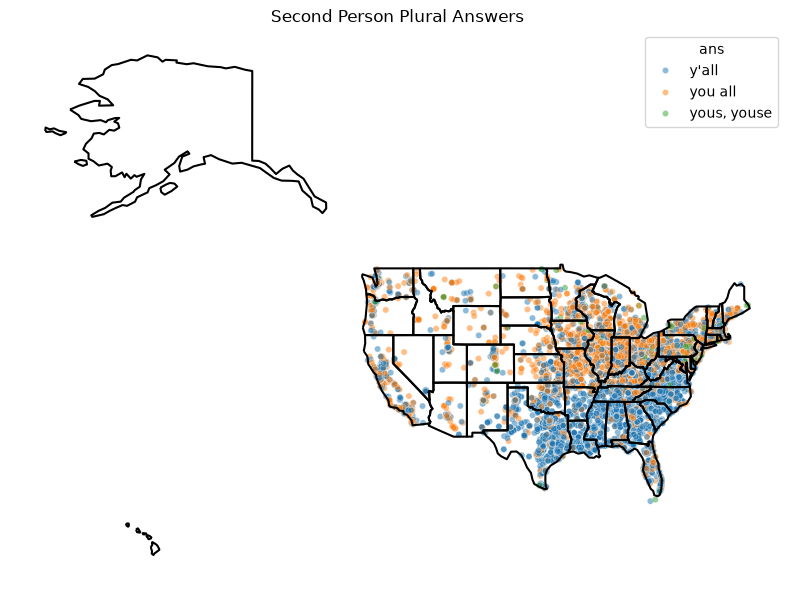

In [4]:
def my_map_theme():
    """Hide the current axes for the supplied exploratory map examples.

    Returns:
        None. Modifies the current matplotlib axes in place.
    """
    plt.axis('off')

plural_second_person = ling_data[(ling_data['Q050'].isin([1, 2, 9])) & (ling_data['long'] > -125)]
answers_q50 = question_data['ans.50']

answers_q50['Q050'] = (answers_q50.index + 1).astype(str)
plural_second_person['Q050'] = plural_second_person['Q050'].astype(str)
plural_second_person = plural_second_person.merge(answers_q50, on='Q050', how='inner')
plural_second_person['ans'] = plural_second_person['ans'].cat.remove_unused_categories()

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plural_second_person, x='long', y='lat', hue='ans', s=20, alpha=0.5)
state_df.boundary.plot(ax=plt.gca(), color='black')
my_map_theme()
plt.title("Second Person Plural Answers")
plt.show()

C:\Users\mgrin\miniconda3\envs\stat215a\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


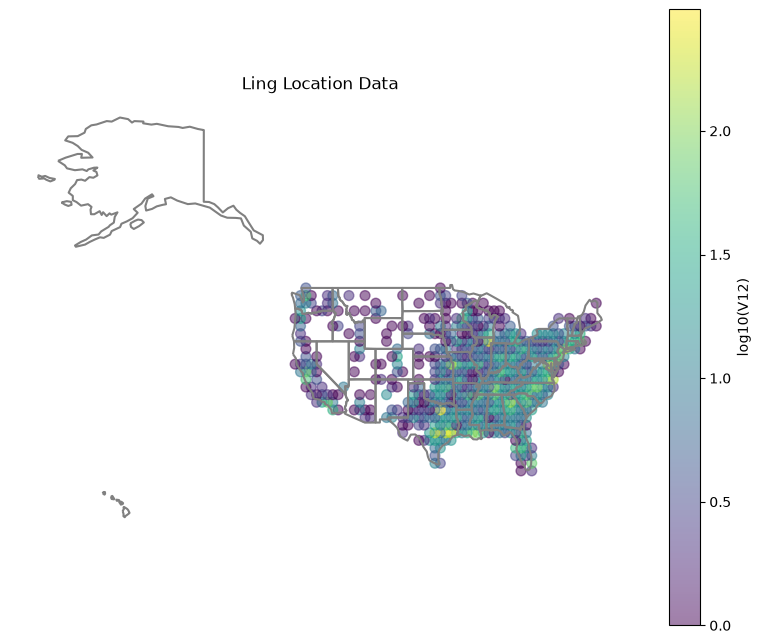

In [5]:

ling_location_filtered = ling_location[ling_location['Longitude'] > -125]

plt.figure(figsize=(10, 8))
plt.scatter(ling_location_filtered['Longitude'],
            ling_location_filtered['Latitude'],
            c=np.log10(ling_location_filtered['V12']),
            cmap='viridis', s=50, alpha=0.5)
state_df.boundary.plot(ax=plt.gca(), color='gray')
my_map_theme()
plt.colorbar(label='log10(V12)')
plt.title("Ling Location Data")
plt.show()



In [6]:
for _, row in question_data["quest.use"].iterrows():
    q = int(row["qnum"])
    print(f"\nQ{q}: {row['quest']}")
    answers = question_data[f"ans.{q}"]
    for code, (_, answer) in enumerate(answers.iterrows(), start=1):
        print(f"  {code} ({answer['ans.let']}): {answer['ans']}")


Q50: What word(s) do you use to address a group of two or more people?
  1 (a): you all
  2 (b): yous, youse
  3 (c): you lot
  4 (d): you guys
  5 (e): you 'uns
  6 (f): yins
  7 (g): you
  8 (h): other
  9 (i): y'all 

Q51: Would you say 'Are you coming with?' as a full sentence, to mean 'Are you coming with us?'
  1 (a): yes
  2 (b): no
  3 (c): other 

Q52: Would you say 'where are you at?' to mean 'where are you?'
  1 (a): yes
  2 (b): no
  3 (c): I can use "where are you at" in contexts such as asking someone how s/he is coming along on a project, but not in the general sense of "where are you physically located in the world at this moment". 

Q53: Modals are words like 'can,' 'could,' 'might,' 'ought to,' and so on. Can you use more than one modal at a time? (e.g., 'I might could do that' to mean 'I might be able to do that'; or 'I used to could do that' to mean 'I used to be able to do that')
  1 (a): yes (please consider adding which combinations of modals you use in the comm